In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

In [3]:
train_folder = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/training"
test_folder = "/kaggle/input/datasets/awsaf49/mnist-dataset/mnist_png/testing"

def load_images(folder):
    images = []

    for label in sorted(os.listdir(folder)):
        label_path = os.path.join(folder, label)

        if not os.path.isdir(label_path):
            continue

        for filename in os.listdir(label_path):
            img_path = os.path.join(label_path, filename)

            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            img = img.astype("float32") / 255.0

            images.append(img)

    return np.array(images)

x_train = load_images(train_folder)
x_test = load_images(test_folder)

print("Training Images:", x_train.shape)
print("Testing Images :", x_test.shape)

Training Images: (60000, 28, 28)
Testing Images : (10000, 28, 28)


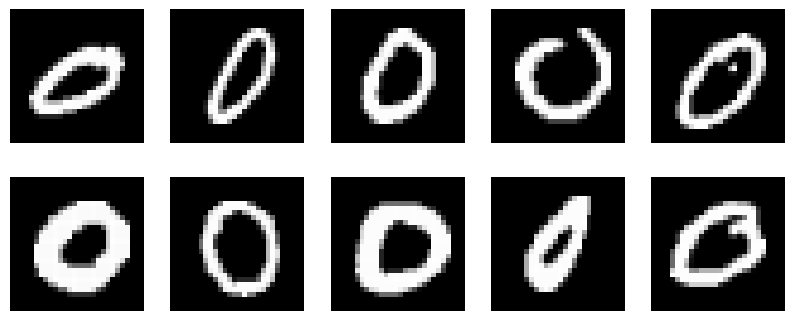

In [4]:
plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.axis('off')

plt.show()

In [5]:
x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

print(x_train.shape)
print(x_test.shape)

(60000, 28, 28, 1)
(10000, 28, 28, 1)


# Add Noise

In [6]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)

x_train_noisy = np.clip(x_train_noisy,0.,1.)
x_test_noisy = np.clip(x_test_noisy,0.,1.)

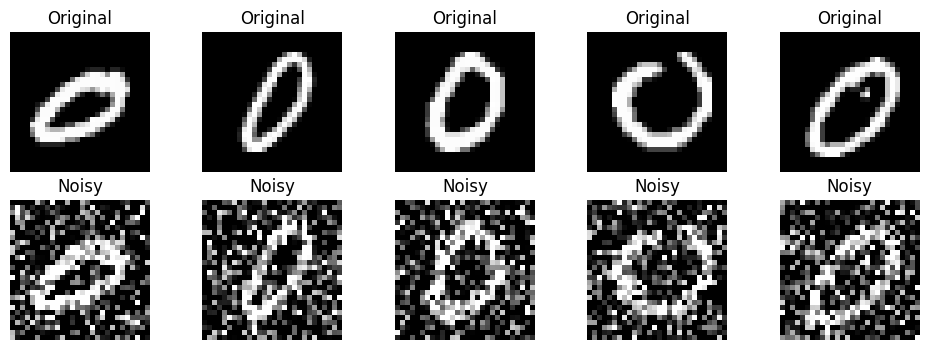

In [7]:
plt.figure(figsize=(12,4))

for i in range(5):

    # Original
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.show()

# Build the Autoencoder

In [8]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(28, 28, 1))

# =====================
# Encoder
# =====================

x = Conv2D(32, (3,3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2,2), padding='same')(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2,2), padding='same')(x)

# =====================
# Decoder
# =====================

x = Conv2D(64, (3,3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2,2))(x)

x = Conv2D(32, (3,3), activation='relu', padding='same')(x)
x = UpSampling2D((2,2))(x)

decoded = Conv2D(1, (3,3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.summary()

2026-07-05 17:29:35.536231: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

# Train the Model

In [10]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=20,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 54s 112ms/step - loss: 0.1661 - val_loss: 0.1144
Epoch 2/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - loss: 0.1114 - val_loss: 0.1064
Epoch 3/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 112ms/step - loss: 0.1058 - val_loss: 0.1030
Epoch 4/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 111ms/step - loss: 0.1030 - val_loss: 0.1012
Epoch 5/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - loss: 0.1014 - val_loss: 0.0995
Epoch 6/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - loss: 0.1001 - val_loss: 0.0986
Epoch 7/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 52s 110ms/step - loss: 0.0991 - val_loss: 0.0977
Epoch 8/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 110ms/step - loss: 0.0983 - val_loss: 0.0974
Epoch 9/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - loss: 0.0977 - val_loss: 0.0971
Epoch 10/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - loss: 0.0971 - val_loss: 0.0965
Epoch 11/20
469/469 ━━━━━━━━━━━━━━━━━━━━ 51s 109ms/step - loss: 0.0966 - val_loss: 0.0960
Epoch 12/20
469/469

In [11]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step


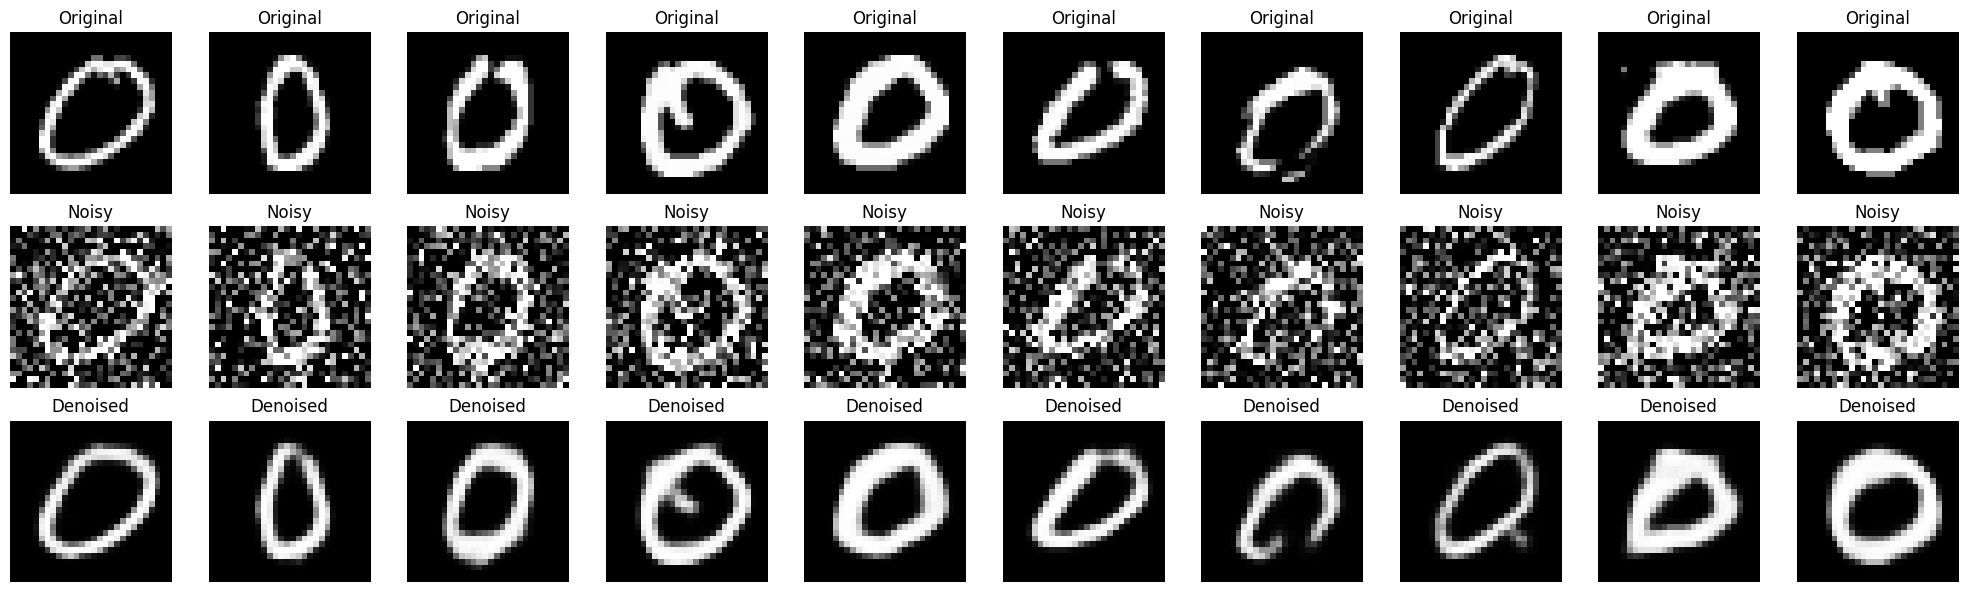

In [12]:
import matplotlib.pyplot as plt

n = 10

plt.figure(figsize=(20,6))

for i in range(n):

    # Original
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.title("Original")
    plt.axis("off")

    # Noisy
    ax = plt.subplot(3, n, i + n + 1)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # Denoised
    ax = plt.subplot(3, n, i + 2*n + 1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Plot Loss Graph

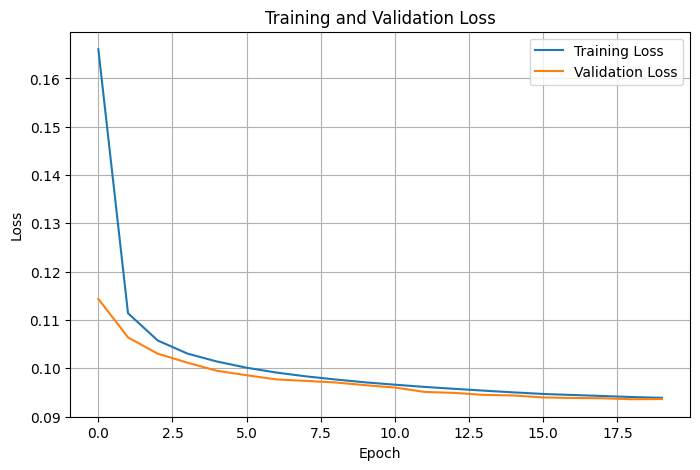

In [13]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.grid(True)

plt.show()

In [15]:
autoencoder.save("mnist_denoising_autoencoder.keras")

print("done")

done
